Notebook demonstrating how ODE simulations and linear framework solutions can have similar outputs for the Control model

In [9]:
from pysb import Model, Parameter, Compartment, Monomer, Parameter, Rule, Initial, Observable
from pysb.simulator import ScipyOdeSimulator
import numpy as np
import cython
import matplotlib.pyplot as plt
import sympy as sp
import pickle
from collections import Counter
import sys, os
from src.PySBtoLF_func import generate_graphs,adapt_graph_get_rhos
from time import time
from scipy.optimize import least_squares

We generate a model of the binding of IL10 to 2 RA receptors and 2 RB receptors without binding of STAT1 and STAT3, whose binding is added later as a quasi steady state. We also generate a model with all interactions to one where repeated complexes (ILRA1=ILRA2) are combined, thus cutting by half the number of edges and nodes

In [10]:
def func_time(IL10):
    if IL10 > 1e-7:
        return 0.1*5,1e4
    else:
        IL10 = abs(np.log10(IL10)) - 3
        return 10**(IL10)/(1e4)*5,10**(IL10)

In [19]:
# Model with binding to two IL10RA
def model_func_full(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2','B_t'], {'B_t': ['QB','TB','DB','SB','U']})
    Monomer('RA', ['bA'])
    Monomer('RB', ['bB'])
    
    # Parameters (We put whatever number)
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])
    
    # Complexes and reactions (binding of receptors)
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U')
    ILM_free = ILM()
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') % RA(bA=1)
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None)| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RA2_alone = IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') % RA(bA=1)
    Rule('IL_RA2_alone_binding', IL_free + RA(bA=None) | IL_RA2_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RB1_alone = IL(bA1=None, bA2=None, bB1=1, bB2=None, B_t='SB') % RB(bB=1)
    Rule('IL_RB1_binding_alone', IL_free + RB(bB=None) | IL_RB1_alone, *[K_IL_RB_f, K_IL_RB_b])
    IL_RB2_alone = IL(bA1=None, bA2=None, bB1=None, bB2=1, B_t='SB') % RB(bB=1)
    Rule('IL_RB2_binding_alone', IL_free + RB(bB=None) | IL_RB2_alone, *[K_IL_RB_f, K_IL_RB_b])
    
    IL_noRA1_SB = IL(bA1=None, B_t='SB')
    IL_RA1_DB = IL(bA1=1, B_t='DB') % RA(bA=1)
    Rule('IL_RA1_binding_DB', IL_noRA1_SB + RA(bA=None) | IL_RA1_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_noRA2_SB = IL(bA2=None, B_t='SB')
    IL_RA2_DB = IL(bA2=2, B_t='DB') % RA(bA=2)
    Rule('IL_RA2_binding_DB', IL_noRA2_SB + RA(bA=None) | IL_RA2_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA1_noRB1_SB = IL(bA1=None, bB1=None, B_t='SB')
    IL_noRA1_RB1_DB = IL(bA1=None, bB1=3, B_t='DB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_DB', IL_noRA1_noRB1_SB + RB(bB=None) | IL_noRA1_RB1_DB, *[K_IL_RB2_f, K_IL_RB2_b])
    IL_noRA2_noRB2_SB = IL(bA2=None, bB2=None, B_t='SB')
    IL_noRA2_RB2_DB = IL(bA2=None, bB2=4, B_t='DB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_DB', IL_noRA2_noRB2_SB + RB(bB=None) | IL_noRA2_RB2_DB, *[K_IL_RB2_f, K_IL_RB2_b])

    IL_RA1_noRB1_SB = IL(bA1=1, bB1=None, B_t='SB') % RA(bA=1)
    IL_RA1_RB1_DB = IL(bA1=1, bB1=2, B_t='DB') % RA(bA=1) % RB(bB=2)
    Rule('IL_RA1_RB1_binding_DB', IL_RA1_noRB1_SB + RB(bB=None) | IL_RA1_RB1_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_RA2_noRB2_SB = IL(bA2=1, bB2=None, B_t='SB') % RA(bA=1)
    IL_RA2_RB2_DB = IL(bA2=1, bB2=2, B_t='DB') % RA(bA=1) % RB(bB=2)
    Rule('IL_RA2_RB2_binding_DB', IL_RA2_noRB2_SB + RB(bB=None) | IL_RA2_RB2_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])

    IL_noRA1_DB = IL(bA1=None, B_t='DB')
    IL_RA1_TB = IL(bA1=1, B_t='TB') % RA(bA=1)
    Rule('IL_RA1_binding_TB', IL_noRA1_DB + RA(bA=None) | IL_RA1_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_noRA2_DB = IL(bA2=None, B_t='DB')
    IL_RA2_TB = IL(bA2=2, B_t='TB') % RA(bA=2)
    Rule('IL_RA2_binding_TB', IL_noRA2_DB + RA(bA=None) | IL_RA2_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_RA1_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1)
    IL_RA1_RB1_TB = IL(bA1=1, bB1=3, B_t='TB') % RA(bA=1) % RB(bB=3)
    Rule('IL_RA1_RB1_binding_TB', IL_RA1_noRB1_DB + RB(bB=None) | IL_RA1_RB1_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_noRA1_noRB1_DB = IL(bA1=None, bB1=None, B_t='DB')
    IL_noRA1_RB1_TB = IL(bA1=None, bB1=3, B_t='TB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_TB', IL_noRA1_noRB1_DB + RB(bB=None) | IL_noRA1_RB1_TB, *[K_IL_RB2_f, K_IL_RB2_b])
    
    IL_RA2_noRB2_DB = IL(bA2=2, bB2=None, B_t='DB') % RA(bA=2)
    IL_RA2_RB2_TB = IL(bA2=2, bB2=4, B_t='TB') % RA(bA=2) % RB(bB=4)
    Rule('IL_RA2_RB2_binding_TB', IL_RA2_noRB2_DB + RB(bB=None) | IL_RA2_RB2_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_noRA2_noRB2_DB = IL(bA2=None, bB2=None, B_t='DB')
    IL_noRA2_RB2_TB = IL(bA2=None, bB2=4, B_t='TB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_TB', IL_noRA2_noRB2_DB + RB(bB=None) | IL_noRA2_RB2_TB, *[K_IL_RB2_f, K_IL_RB2_b])

    IL_noRA1_TB = IL(bA1=None, bA2=2, bB1=3, bB2=4, B_t='TB') % RA(bA=2) % RB(bB=3) % RB(bB=4)
    IL_RA1_RA2_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1) % RA(bA=2) % RB(bB=3) % RB(bB=4)
    Rule('IL_RA1_binding_fin', IL_noRA1_TB + RA(bA=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_noRA2_TB = IL(bA1=1, bA2=None, bB1=3, bB2=4, B_t='TB') % RA(bA=1) % RB(bB=3) % RB(bB=4)
    Rule('IL_RA2_binding_fin', IL_noRA2_TB + RA(bA=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_RA1_noRB1_TB = IL(bA1=1, bA2=2, bB1=None, bB2=4, B_t='TB') % RA(bA=1) % RA(bA=2) % RB(bB=4)
    Rule('IL_RA1_RB1_binding_fin', IL_RA1_noRB1_TB+ RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_RA2_noRB2_TB = IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') % RA(bA=1) % RA(bA=2) % RB(bB=3)
    Rule('IL_RA2_RB2_binding_fin', IL_RA2_noRB2_TB + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #IC["IL0"]*Na*PA["vol_EC"])
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None) ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC)
    Observable('RA_free', RA(bA=None) ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1) ** Cell_PM)
    Observable('IL_RA2', IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1) ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    Observable('IL_RB2', IL(bA1=None, bA2=None, bB1=None, bB2=1, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None, B_t='DB') ** EC % RA(bA=1) ** Cell_PM % RA(bA=2) ** Cell_PM)
    Observable('IL_RA1_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2_RB1', IL(bA1=None, bA2=1, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2_RB2', IL(bA1=None, bA2=1, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2, B_t='DB') ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') ** EC % RA(bA=1) ** Cell_PM % RA(bA=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RA2_RB2', IL(bA1=1, bA2=2, bB1=None, bB2=3, B_t='TB') ** EC % RA(bA=1) ** Cell_PM % RA(bA=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RB1_RB2', IL(bA1=1, bA2=None, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA2_RB1_RB2', IL(bA1=None, bA2=1, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)

    Observable('IL_RA1_RA2_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1) ** Cell_PM % RA(bA=2) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    
    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf/1,dT/100)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()
    return simulator.all

def model_func_simpl(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2'])
    Monomer('RA', ['bA'])
    Monomer('RB', ['bB']) 
    
    # Parameters (We put whatever number)
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', 2*PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', 2*PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])
    
    Parameter('K_IL_RA2_2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    Parameter('K_IL_RB2_2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    
    Parameter('K_IL_RA2_3_b', PA["k_IL_RA_b"]*(1/2))
    Parameter('K_IL_RA_RB_3_b', PA["k_IL_RA_RB_b"]*(1/2))
    
    Parameter('K_IL_RA2_4_b', PA["k_IL_RA_b"]*2)
    Parameter('K_IL_RA_RB_4_b', PA["k_IL_RA_RB_b"]*2)
    
    # Complexes and reactions (binding of receptors)
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None)
    ILM_free = ILM()
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None) % RA(bA=1)
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None)| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RB1_alone = IL(bA1=None, bA2=None, bB1=1, bB2=None) % RB(bB=1)
    Rule('IL_RB1_binding_alone', IL_free + RB(bB=None) | IL_RB1_alone, *[K_IL_RB_f, K_IL_RB_b])
    
    # Binding of second receptors from IL-RA1 complex
    IL_RA1_RA2 = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1) % RA(bA=2)
    Rule('IL_RA1_RA2_binding_DB', IL_RA1_alone + RA(bA=None) | IL_RA1_RA2, *[K_IL_RA2_2_f, K_IL_RA2_b])
    IL_RA1_RB1 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1) % RB(bB=2)
    Rule('IL_RA1_RB1_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_RA1_RB2 = IL(bA1=1, bA2=None, bB1=None, bB2=2) % RA(bA=1) % RB(bB=2)
    Rule('IL_RA1_RB2_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB2, *[K_IL_RB2_f, K_IL_RB2_b])
    
    # Binding of second receptors from IL-RB1 complex
    Rule('IL_RB1_RA1_binding_DB', IL_RB1_alone + RA(bA=None) | IL_RA1_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RB2_RA1_binding_DB', IL_RB1_alone + RA(bA=None) | IL_RA1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])  # IL-RA1-RB2 is the same complex as IL-RA2-RB1
    IL_RB1_RB2 = IL(bA1=None, bA2=None, bB1=1, bB2=2) % RB(bB=1) % RB(bB=2)
    Rule('IL_RB1_RB2_binding_DB', IL_RB1_alone + RB(bB=None) | IL_RB1_RB2, *[K_IL_RB2_2_f, K_IL_RB2_b])
    
    # Binding of third receptors to from IL-RA1-RA2-RB1 complex
    IL_RA1_RA2_RB1 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1) % RA(bA=2) % RB(bB=3)
    Rule('IL_RA1RA1_RB1_binding_TB', IL_RA1_RA2 + RB(bB=None) | IL_RA1_RA2_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_3_b])
    Rule('IL_RA1RB1_RA2_binding_TB', IL_RA1_RB1 + RA(bA=None) | IL_RA1_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_RA1RB2_RA2_binding_TB', IL_RA1_RB2 + RA(bA=None) | IL_RA1_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    
    # Binding of third receptors to from IL-RA1-RB1-RB2 complex
    IL_RA1_RB1_RB2 = IL(bA1=1, bA2=None, bB1=2, bB2=3) % RA(bA=1) % RB(bB=2) % RB(bB=3)
    Rule('IL_RA1RB1_RB2_binding_TB', IL_RA1_RB1 + RB(bB=None) | IL_RA1_RB1_RB2, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_RA1RB2_RB1_binding_TB', IL_RA1_RB2 + RB(bB=None) | IL_RA1_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RB1RB2_RA2_binding_TB', IL_RB1_RB2 + RA(bA=None) | IL_RA1_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_3_b])
    
    # Binding of fourth receptor
    IL_RA1_RA2_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1) % RA(bA=2) % RB(bB=3) % RB(bB=4)
    Rule('IL_RA1RA2RB1_RB2_binding_QB', IL_RA1_RA2_RB1 + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_4_b])
    Rule('IL_RA1RB1RB2_RA2_binding_QB', IL_RA1_RB1_RB2 + RA(bA=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_4_b])
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #IC["IL0"]*Na*PA["vol_EC"])
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None) ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC)
    Observable('RA_free', RA(bA=None) ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None) ** EC % RA(bA=1) ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None) ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1) ** Cell_PM % RA(bA=2) ** Cell_PM)
    Observable('IL_RA1_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None) ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2) ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2) ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    
    Observable('IL_RA1_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1) ** Cell_PM % RA(bA=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RB1_RB2', IL(bA1=1, bA2=None, bB1=2, bB2=3) ** EC % RA(bA=1) ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    
    Observable('IL_RA1_RA2_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1) ** Cell_PM % RA(bA=2) ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)

    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf,dT/500)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()

    return simulator.all

With the simplified model with non-repeated complexes we can generate the SS solution via the linear framework

In [16]:
def model_function(PA,IC):
    def IL10_model_RA_RB(x):
        RA = x[0]
        RB = x[1]
        IL10M = x[2]
        
        RA_expr = -IL10M0/2*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3))/(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + K_ILM_b*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3)/2) - RA + RA0
        RB_expr = -IL10M0/2*(4*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3))/(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + K_ILM_b*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3)/2) - RB + RB0
        ILM_expr = -IL10M - IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3))/(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + K_ILM_b*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3)/2) + IL10M0
        return [RA_expr,RB_expr,ILM_expr]
    
    def SS_IL10_model_RA_RB():
        ILRA1RB1 = -IL10M0/2*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3))/(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + K_ILM_b*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3)/2) - RA + RA0
        ILRA1RA2RB1 = -IL10M0/2*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3))/(2*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + K_ILM_b*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3)/2)) - RA/2 + RA0/2
        ILRA1RB1RB2 = -IL10M0/2*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3))/(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + K_ILM_b*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3)/2) - RA + RA0
        ILRA1RA2RB1RB2 = -IL10M0/2*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3))/(2*(2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 9*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 38*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 77*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 25*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 38*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 7*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 14*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 34*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 8*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 54*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 84*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 66*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 51*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 60*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 9*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 24*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 9*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 15*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 22*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 48*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 20*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 3*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 7*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 5*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 17*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 34*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 54*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 81*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 61*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 34*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 4*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 34*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 5*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 21*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 49*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RA*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**3 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*RB**2*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**5*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 64*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 31*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 53*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 54*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 63*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 74*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 41*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 38*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 38*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_b*RB*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**4 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3) + IL10M*K_ILM_f*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB**2*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA + K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA + 5*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2 + 3*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 53*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 38*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 57*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**2 + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 3*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 7*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 22*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA + 7*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 35*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 40*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 55*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 49*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 47*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 101*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 43*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 49*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 43*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 26*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 21*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 14*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_f**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**3*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*RA**2*RB*(4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 3*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 8*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 9*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 3*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 2*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 9*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 27*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 19*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 23*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 6*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 9*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_f*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*RA**4 + 8*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 48*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 43*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3 + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 59*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 52*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 29*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 46*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 87*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 37*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 31*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 17*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*RA**2*(4*K_IL_RA2_b**5*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB_f*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 6*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB_f*RA*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**2 + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**3*K_IL_RB_f*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 15*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 14*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 6*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB_b*RA**3 + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB_f*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**2 + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 39*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 45*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 16*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 19*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 17*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*RA**4 + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**3 + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**3 + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 27*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB_f*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**2 + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA*RB + 21*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 25*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 75*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RB**3 + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 41*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 33*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RB + 42*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b + 5*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 12*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 13*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 19*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA**5 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RB_f*RA**4*RB + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_f*RA**3*RB**2 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_f*RA**3*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*RA**4 + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB_f*RA**3*RB + 13*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RB_f*RA**2*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_f*RA**2*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*RA**3 + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB_b*RA**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 22*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_f*RA**2*RB**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA**2*RB**2 + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**3*RB + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**3*RB + 32*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA**2*RB**2 + 23*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**3 + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA**2*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*RA**3 + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**3 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB_f*RA**2*RB + 26*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA**2*RB**2 + 11*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_f*RA*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*RA**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB_b*RA**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB_f*RA*RB + 9*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_f*RA*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*RA**2*RB + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB_b*RA**2*RB + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 19*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 20*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*RA**2 + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 35*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*RA**2*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB_b*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_f*RA*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RA*RB**2 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA**2*RB + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA**2*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RA*RB**2 + 41*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**3 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**4 + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RA*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*RA**2 + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**3*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**3*K_IL_RB_f*RA*RB + 13*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RA*RB**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RA*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**3*K_IL_RB_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*RA + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b**2*K_IL_RB_f*RB + 9*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 19*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB + 10*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*RA + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**3*K_IL_RB_f*RB + 13*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 11*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**3*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_f*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_f*RB**5 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_f*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*RA*RB + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**3*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_f*RB**2 + 18*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**4 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**3*K_IL_RB_f*RB**5 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_f*RB + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_f*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_f*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RA + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA_RB_b**4*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 6*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b + 6*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA_RB_b**3*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3) + K_ILM_b*K_IL_RA2_b*(4*K_IL_RA2_b**5*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 4*K_IL_RA2_b**5*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 4*K_IL_RA2_b**5*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 14*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 17*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 10*K_IL_RA2_b**4*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 12*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 14*K_IL_RA2_b**4*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 12*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 4*K_IL_RA2_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 8*K_IL_RA2_b**4*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 4*K_IL_RA2_b**4*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 22*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**2 + 16*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 14*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 46*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 29*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 50*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 39*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 30*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 21*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 34*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 18*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 11*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 24*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 21*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 31*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 23*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 44*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 35*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 18*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 13*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 18*K_IL_RA2_b**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 26*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 4*K_IL_RA2_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*RA**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 60*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 23*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 15*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA*RB + 11*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 47*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 61*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 66*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 85*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 76*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 26*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 49*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 25*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 33*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 31*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 13*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RB**2 + 30*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 13*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 41*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 11*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 34*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 37*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 60*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 35*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 21*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 13*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 18*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 22*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 12*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 6*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*RA**4 + 4*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB_b*RA**4*RB + 12*K_IL_RA2_b*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*RA**4 + 18*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*RA**3 + 26*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB_b*RA**3*RB + 64*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**3 + 2*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 11*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + 3*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB_b*RA**2*RB + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB_b*RA**2*RB**2 + 91*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 39*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 37*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB_b*RA**2*RB**3 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 35*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 19*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA**2*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 11*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB**2 + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RB2_f*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB_b*RA*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA + 7*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 27*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA*RB**2 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 19*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 69*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA + 26*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 39*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 15*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA*RB**3 + 23*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 36*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 29*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 34*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**3 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB_b*RA*RB**4 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**3 + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RA*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RA*RB**4 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 15*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 17*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**3*K_IL_RB_b*RB + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 9*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 11*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RB**3 + 12*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 10*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 30*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**4 + 20*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b**2*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**4*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RB**4 + 4*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**3*K_IL_RB_b*RB**3 + 6*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**4 + 2*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RB2_b*K_IL_RB2_f**2*K_IL_RB_b*RB**5 + 4*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3 + 4*K_IL_RA2_f**5*K_IL_RA_RB_b**2*K_IL_RA_b*RA**5 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b**3*K_IL_RA_b*RA**4 + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**4*RB + 12*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*RA**4 + 5*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*RA**4*RB + 2*K_IL_RA2_f**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB_b*RA**4 + 8*K_IL_RA2_f**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**4*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**4*K_IL_RA_b*RA**3 + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*RA**3 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*RA**3*RB + 4*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB_b*RA**3 + 8*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 48*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**3*RB + 7*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**3*RB**2 + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**3*RB + 12*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*RA**3 + 10*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB + 6*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3 + K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f**2*RA**3*RB**2 + 2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**3*RB + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**3*RB**2 + 16*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**3*RB + 10*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**3*RB**2 + 4*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**3*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_f*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB_b*RA**2 + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*RA**2*RB + 3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**2 + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB_b*RA**2*RB + 16*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*RA**2 + 11*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 32*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_f*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB_b*RA**2*RB**2 + 52*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB + 29*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**2 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f**2*RA**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*RA**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB + 6*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2 + K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*RA**2*RB**3 + 24*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA**2*RB**2 + 12*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA**2*RB + 10*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA**2*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA**2*RB + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*RA + K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA + 20*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*RA*RB + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*RA + 5*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA + K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB + 24*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*RA*RB + 20*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**2 + 26*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b*K_IL_RB_b*RA*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*RA*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*RA*RB**3 + 12*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f**2*RA*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b*K_IL_RB2_f*K_IL_RB_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RA*RB + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RA*RB**2 + 2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b + 10*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b + 2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB_b*RB**3 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**3*K_IL_RB_b*RB**2 + 4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RB2_b**2*K_IL_RB2_f*K_IL_RB_b*RB**3)/2)) - RA/2 + RA0/2
        
        return ILRA1RB1 + ILRA1RA2RB1 + ILRA1RB1RB2 + 2*ILRA1RA2RB1RB2
    
    # Get parameters
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    K_ILM_f = PA["k_ILM_f"]/(Na*PA["vol_EC"])
    K_ILM_b = PA["k_ILM_b"]
    K_IL_RA_f = PA["k_IL_RA_f"]/(Na*PA["vol_EC"])
    K_IL_RA_b = PA["k_IL_RA_b"]
    K_IL_RB_f = PA["k_IL_RB_f"]/(Na*PA["vol_EC"])
    K_IL_RB_b = PA["k_IL_RB_b"]
    K_IL_RA2_f = PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RA2_b = PA["k_IL_RA_b"]
    K_IL_RB2_f = PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RB2_b = PA["k_IL_RB_b"]
    K_IL_RA_RB_f = PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RA_RB_b = PA["k_IL_RA_RB_b"]

    # Get IC
    IL10M0 = IC["IL0"]*Na*PA["vol_EC"]
    RA0 = IC["RA0"]
    RB0 = IC["RB0"]

    result = least_squares(ftol=1e-8,gtol=1e-8, method='dogbox',fun=IL10_model_RA_RB, x0=[RA0/2,RB0/2,IL10M0/2],bounds=([0,0,0],[RA0,RB0,IL10M0]))
    RA,RB,IL10M = result.x
    
    return SS_IL10_model_RA_RB()

In [13]:
PA={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00 # OG: 243.95
}

In [20]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT_full = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_full(PA,IC)
    pSTAT_full.append(simulator['IL_RA1_RB1'][-1]+simulator['IL_RA2_RB2'][-1]+simulator['IL_RA1_RA2_RB1'][-1]+simulator['IL_RA1_RA2_RB2'][-1]+simulator['IL_RA1_RB1_RB2'][-1]+simulator['IL_RA2_RB1_RB2'][-1]+2*simulator['IL_RA1_RA2_RB1_RB2'][-1])

end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 8.972681 seconds


In [15]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT_simpl = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_simpl(PA,IC)
    pSTAT_simpl.append(simulator['IL_RA1_RB1'][-1]+simulator['IL_RA1_RA2_RB1'][-1]+simulator['IL_RA1_RB1_RB2'][-1]+simulator['IL_RA1_RA2_RB1_RB2'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 23.337940 seconds


In [17]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT_rho = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    pSTAT_rho.append(model_function(PA,IC))
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 3.514022 seconds


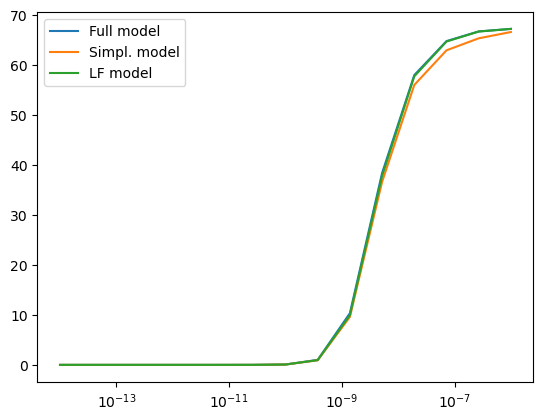

In [21]:
plt.plot(IL10vec,pSTAT_full, label = "Full model")
plt.plot(IL10vec,pSTAT_simpl, label = "Simpl. model")
plt.plot(IL10vec,pSTAT_rho, label = "LF model")
plt.xscale("log")
plt.legend(loc="best")

As we can see the LF SS solution of the simplified model is 10x faster and fits perfectly the original model with all interactions and repeated complexes. The simulation of the simlified model differs a little bit due to numerical problems.

Now we want to see the behavior of the model regarding the differential response of STAT1 and STAT3 signaling in IL-10 mutants with increased binding to RB.

In [4]:
PA={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00, # OG: 243.95
    "k_STAT1_f" : 6.55E+06*10,
    "k_STAT1_b" : 0.678,
    "k_M_f" : 6.55E+06*1000,
    "k_M_b" : 0.678,
    "k_STAT3_f" : 6.55E+06*1000,
    "k_STAT3_b" : 0.678,
    "k_PHOS" : 3.16E-03,
    "k_DEPHOS" : 0.000664996232095083
}

PA_mut={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394/10, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00/10, # OG: 243.95
    "k_STAT1_f" : 6.55E+06*10,
    "k_STAT1_b" : 0.678,
    "k_M_f" : 6.55E+06*1000,
    "k_M_b" : 0.678,
    "k_STAT3_f" : 6.55E+06*1000,
    "k_STAT3_b" : 0.678,
    "k_PHOS" : 3.16E-03,
    "k_DEPHOS" : 0.000664996232095083
}

In [20]:
start_time = time()
Na=6.023e23
Width_PM = 1e-7 # In dm
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT1_WT = []
pSTAT3_WT = []
pSTAT1_mut = []
pSTAT3_mut = []
for IL10 in IL10vec:
    IC = {
    "IL0":IL10,
    "RA0":750,
    "RB0":2323,
    "STAT10" : 4858.2479731492,
    "STAT30" : 477858.2479731492
    }
    # IL10 WT
    C0 = simulate_model(PA,IC)
    KbS = PA["k_STAT1_f"]/(Na*PA["vol_cell"])
    KuS = PA["k_STAT1_b"]
    KpS = PA["k_PHOS"]
    KdS = PA["k_DEPHOS"]
    S0 = IC["STAT10"]
    pSTAT1 = ((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))-((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))**2-4*KbS*KdS/KpS*(1+KdS/KpS)*KbS*C0*S0)**(1/2))/(2*KbS*KdS/KpS*(1+KdS/KpS))
    pSTAT1_WT.append(pSTAT1)
    KbS = PA["k_STAT3_f"]/(Na*PA["vol_cell"])
    KuS = PA["k_STAT3_b"]
    KpS = PA["k_PHOS"]
    KdS = PA["k_DEPHOS"]
    S0 = IC["STAT30"]
    pSTAT3 = ((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))-((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))**2-4*KbS*KdS/KpS*(1+KdS/KpS)*KbS*C0*S0)**(1/2))/(2*KbS*KdS/KpS*(1+KdS/KpS))
    pSTAT3_WT.append(pSTAT3)

    # IL10 RB mutant
    C0 = simulate_model(PA_mut,IC)
    KbS = PA["k_STAT1_f"]/(Na*PA["vol_cell"])
    KuS = PA["k_STAT1_b"]
    KpS = PA["k_PHOS"]
    KdS = PA["k_DEPHOS"]
    S0 = IC["STAT10"]
    pSTAT1 = ((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))-((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))**2-4*KbS*KdS/KpS*(1+KdS/KpS)*KbS*C0*S0)**(1/2))/(2*KbS*KdS/KpS*(1+KdS/KpS))
    pSTAT1_mut.append(pSTAT1)
    KbS = PA["k_STAT3_f"]/(Na*PA["vol_cell"])
    KuS = PA["k_STAT3_b"]
    KpS = PA["k_PHOS"]
    KdS = PA["k_DEPHOS"]
    S0 = IC["STAT30"]
    pSTAT3 = ((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))-((KbS*C0+KdS/KpS*(KbS*(C0+S0)+(KuS+KpS)))**2-4*KbS*KdS/KpS*(1+KdS/KpS)*KbS*C0*S0)**(1/2))/(2*KbS*KdS/KpS*(1+KdS/KpS))
    pSTAT3_mut.append(pSTAT3)
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 7.030085 seconds


Text(0, 0.5, 'pSTAT3')

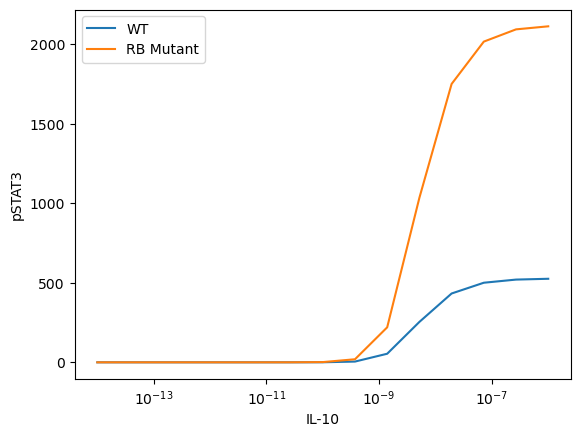

In [21]:
plt.plot(IL10vec,pSTAT3_WT, label="WT")
plt.plot(IL10vec,pSTAT3_mut, label="RB Mutant")
plt.legend(loc="best")
plt.xscale("log")
plt.xlabel("IL-10")
plt.ylabel("pSTAT3")

Text(0, 0.5, 'pSTAT1')

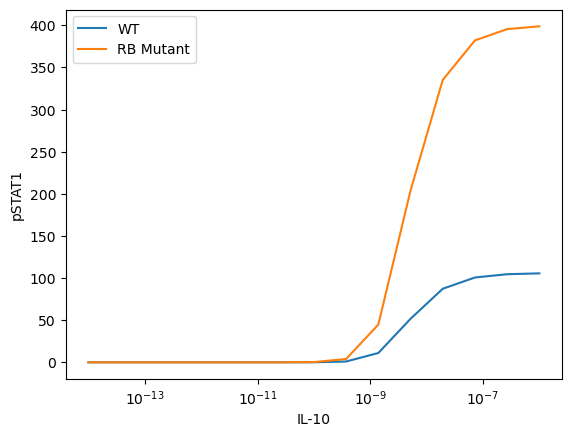

In [22]:
plt.plot(IL10vec,pSTAT1_WT, label="WT")
plt.plot(IL10vec,pSTAT1_mut, label="RB Mutant")
plt.legend(loc="best")
plt.xscale("log")
plt.xlabel("IL-10")
plt.ylabel("pSTAT1")

As we can see the behavior of STAT1 and STAT3 is the same.